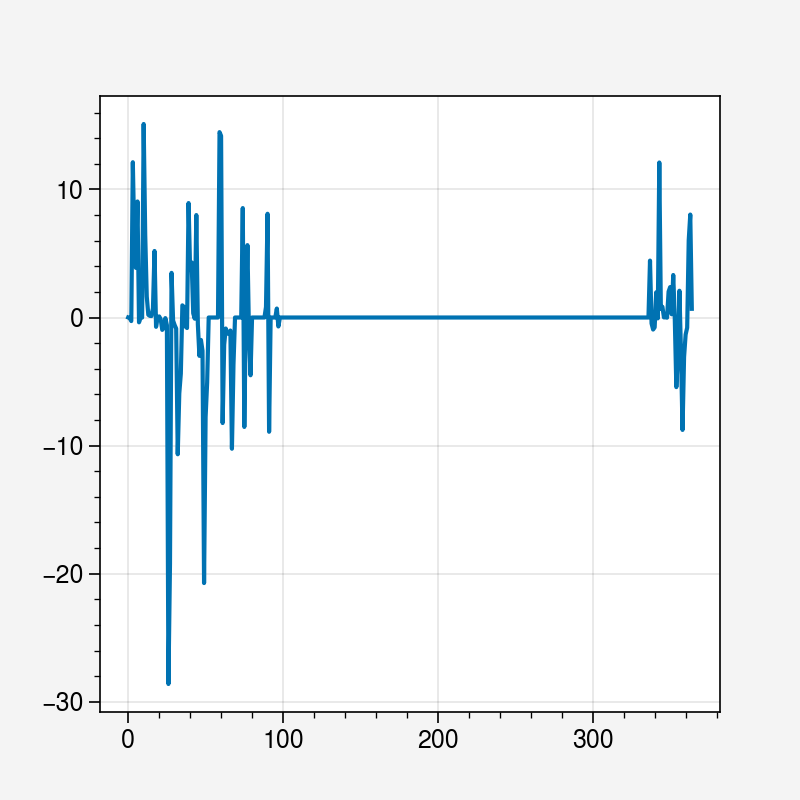

In [34]:
# for an example year

year = 2020
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water

ds_LHF = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.LHF.'+str(year)+'.nc')
LHF = np.array(ds_LHF.LHF[:,jmin:jmax,imin:imax])
ds_SHF = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.SHF.'+str(year)+'.nc')
SHF = np.array(ds_SHF.SHF[:,jmin:jmax,imin:imax])
ds_SWU = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.SWU.'+str(year)+'.nc')
SWU = np.array(ds_SWU.SWU[:,jmin:jmax,imin:imax])
ds_SWD = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.SWD.'+str(year)+'.nc')
SWD = np.array(ds_SWD.SWD[:,jmin:jmax,imin:imax])
ds_LWU = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.LWU.'+str(year)+'.nc')
LWU = np.array(ds_LWU.LWU[:,jmin:jmax,imin:imax])
ds_LWD = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.LWD.'+str(year)+'.nc')
LWD = np.array(ds_LWD.LWD[:,jmin:jmax,imin:imax])

ds_snowfall = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.MBsf.'+str(year)+'.nc')
snowfall = np.array(ds_snowfall.MBsf[:,jmin:jmax,imin:imax])

ds_snowquantity = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/daily/ICE.EC-Earth3_SSP245.EUe.MB.'+str(year)+'.nc')
snowquantity = ds_snowquantity.MB.max(axis=1)[:,jmin:jmax,imin:imax]
snowdiff = np.array(snowquantity[1:]) - np.array(snowquantity[:-1])
plt.plot(snowdiff[:,50,60])

In [35]:
t_day = 86400 # 60*60*24 seconds in a day


snowdiff_nosf = snowdiff - snowfall[1:] # in mm eq. w, or kg.m**(-2)
energy_snowdiff_nosf = snowdiff_nosf*Lf # kg.m**(-2) * J.kg**(-1) = J.m**(-2)
power_snowdiff_nosf = energy_snowdiff_nosf/t_day # in W.m**(-2)
snowmelt = power_snowdiff_nosf - LHF[1:]

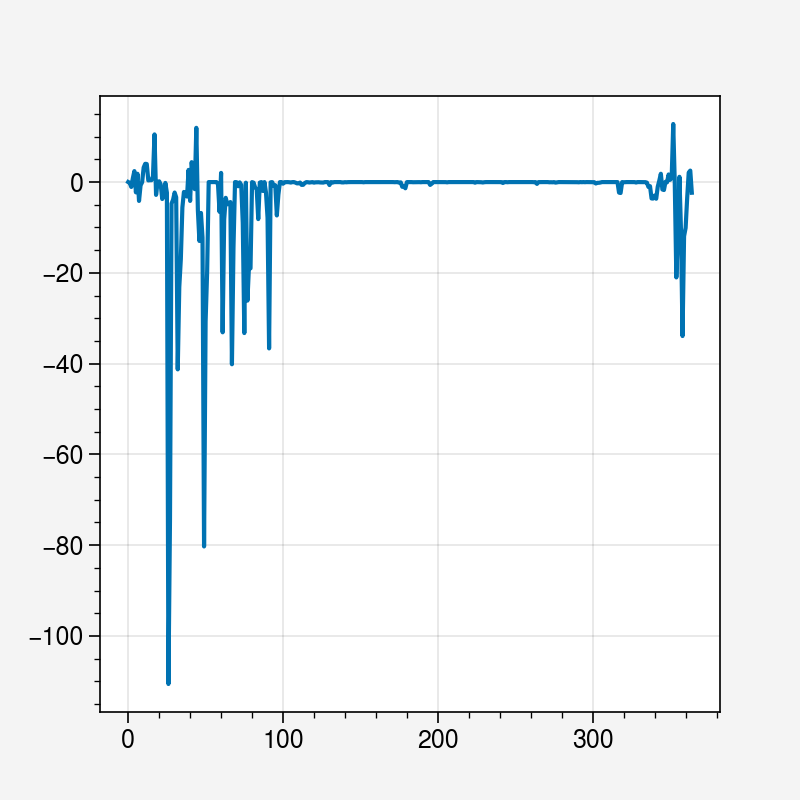

In [36]:
plt.plot(power_snowdiff_nosf[:,50,60])

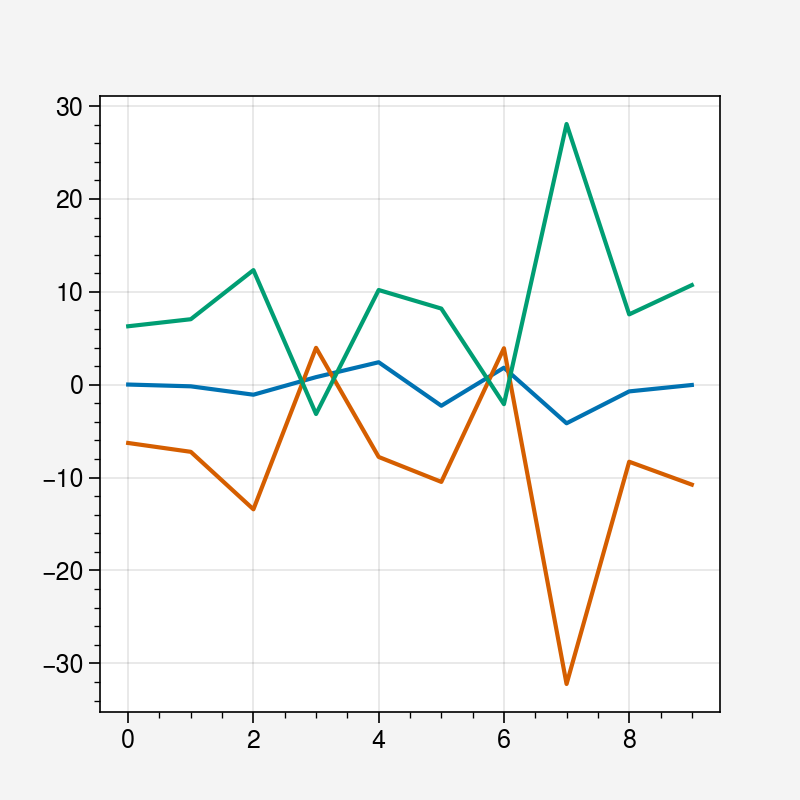

In [37]:
#plt.plot(snowquantity[1:11,50,60])
plt.plot((snowdiff[:10,50,60]-snowfall[1:11,50,60])*Lf/t_day)
plt.plot(LHF[1:11,50,60])
plt.plot(snowmelt[:10,50,60])

In [89]:
# Snow melt energy directly with variable MBm

ds_MBm = xr.open_dataset('/bettik/castelli/data/MAR-EC-Earth3/SSP245/ICE.EC-Earth3_SSP245.EUe.MBm.'+str(year)+'.nc')
ds_FRV = xr.open_dataset('/bettik/castelli/data/MAR-EC-Earth3/ICE.EC-Earth3.EUe.FRV.08.1975.nc')

FRV_sect1 = np.array(ds_FRV.FRV.sel(sector=1.0)[jmin:jmax,imin:imax]/100)
FRV_sect2 = np.array(ds_FRV.FRV.sel(sector=2.0)[jmin:jmax,imin:imax]/100)
FRV_sect3 = np.array(ds_FRV.FRV.sel(sector=3.0)[jmin:jmax,imin:imax]/100)
melt_MBm_sect1 = np.array(ds_MBm.MBm.sel(sector=1.0))[:,jmin:jmax,imin:imax]
melt_MBm_sect2 = np.array(ds_MBm.MBm.sel(sector=2.0))[:,jmin:jmax,imin:imax]
melt_MBm_sect3 = np.array(ds_MBm.MBm.sel(sector=3.0))[:,jmin:jmax,imin:imax]

In [91]:
melt_MBm = melt_MBm_sect1*FRV_sect1 + melt_MBm_sect2*FRV_sect2 + melt_MBm_sect3*FRV_sect3

melt_MBm.shape

(366, 91, 139)

/home/castelli/miniforge3/envs/phd_v1/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


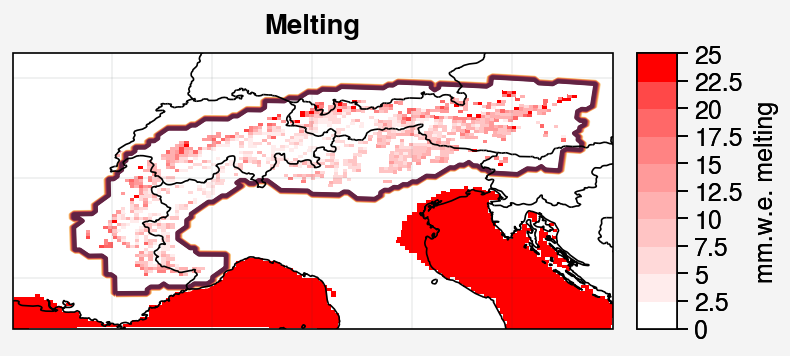

In [96]:
f, axs = pplt.subplots(proj='cyl',axwidth=3)


#cb = axs.pcolormesh(lon,lat,(melt_MBm[100] > 10**10),levels=2,cmap='Red',vmin=0,vmax=1)#'seismic')
cb = axs.pcolormesh(lon,lat,melt_MBm[100],levels=10,cmap='Red',vmin=0,vmax=25)#'seismic')
axs.contour(lon, lat,alps)

f.colorbar(cb, label= 'mm.w.e. melting')

axs.format(**multiplot_format,suptitle='Melting')

/home/castelli/miniforge3/envs/phd_v1/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/miniforge3/envs/phd_v1/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/miniforge3/envs/phd_v1/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/castelli/miniforge3/envs/phd_v1/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, 

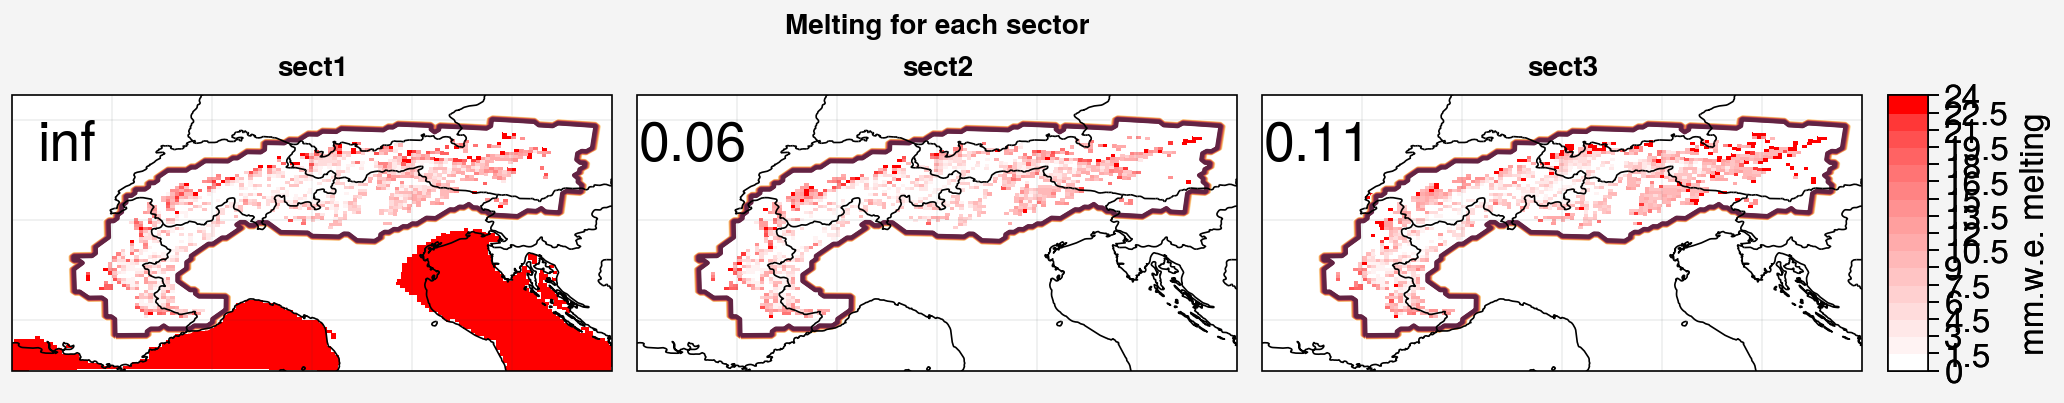

In [65]:
f, axs = pplt.subplots(proj='cyl',ncols=3,axwidth=3)

cb = axs[0].pcolormesh(lon,lat,melt_MBm_sect1[100],levels=21,cmap='Red',vmin=0,vmax=25)#'seismic')
axs[0].contour(lon, lat,alps)
axs[0].text(5.1,47.5,"{:.2f}".format(np.mean(melt_MBm_sect1[0])),ha='center',va='center',fontsize=20)

cb = axs[1].pcolormesh(lon,lat,melt_MBm_sect2[100],levels=21,cmap='Red',vmin=0,vmax=25)#'seismic')
axs[1].contour(lon, lat,alps)
axs[1].text(5.1,47.5,"{:.2f}".format(np.mean(melt_MBm_sect2[0])),ha='center',va='center',fontsize=20)

cb = axs[2].pcolormesh(lon,lat,melt_MBm_sect3[100],levels=21,cmap='Red',vmin=0,vmax=25)#'seismic')
axs[2].contour(lon, lat,alps)
axs[2].text(5.1,47.5,"{:.2f}".format(np.mean(melt_MBm_sect3[0])),ha='center',va='center',fontsize=20)

f.colorbar(cb, label= 'mm.w.e. melting')

axs.format(**multiplot_format,suptitle='Melting for each sector',collabels=['sect1','sect2','sect3'])

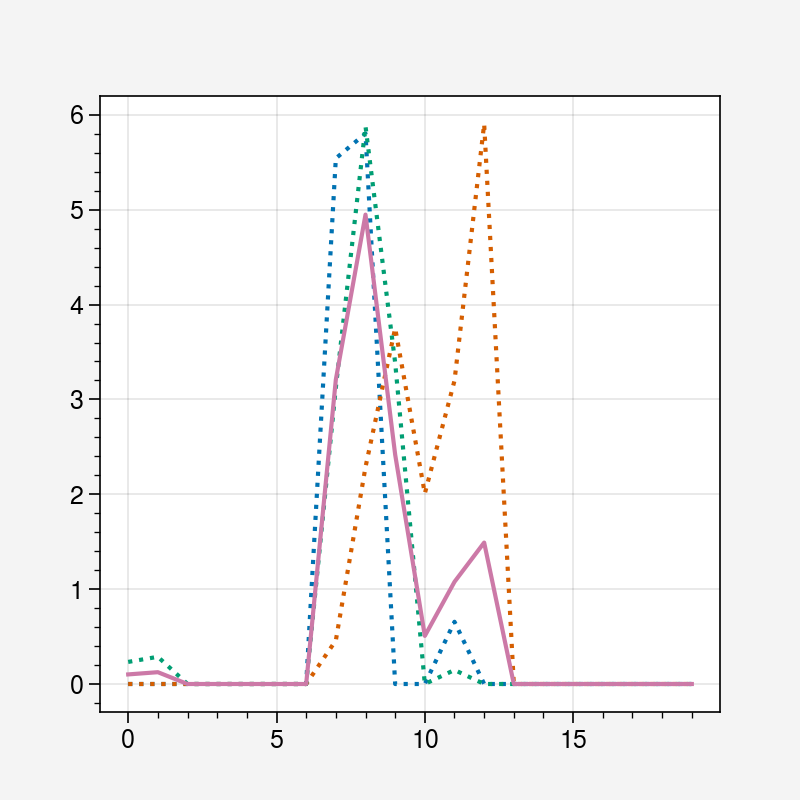

In [97]:
x = 40
y = 70

plt.plot(melt_MBm_sect1[:20,x,y],linestyle=':')
plt.plot(melt_MBm_sect2[:20,x,y],linestyle=':')
plt.plot(melt_MBm_sect3[:20,x,y],linestyle=':')
plt.plot(melt_MBm[:20,x,y])

In [98]:
energy_melt_MBm = melt_MBm*Lf # kg.m**(-2) * J.kg**(-1) = J.m**(-2)
flux_melt_MBm = energy_melt_MBm/t_day # in W.m**(-2)

/tmp/ipykernel_1393589/2663761282.py:1: RuntimeWarning: overflow encountered in multiply
  energy_melt_MBm = melt_MBm*Lf # kg.m**(-2) * J.kg**(-1) = J.m**(-2)


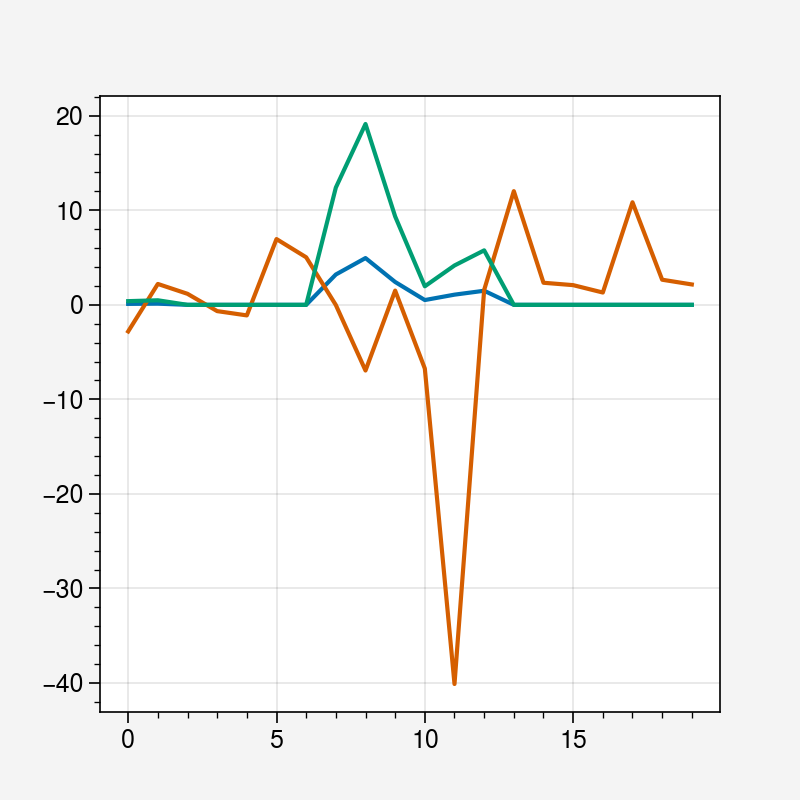

In [99]:
plt.plot(melt_MBm[:20,x,y])
plt.plot(snowmelt[:20,x,y])
plt.plot(flux_melt_MBm[:20,x,y])

<a list of 1 Line2D objects>

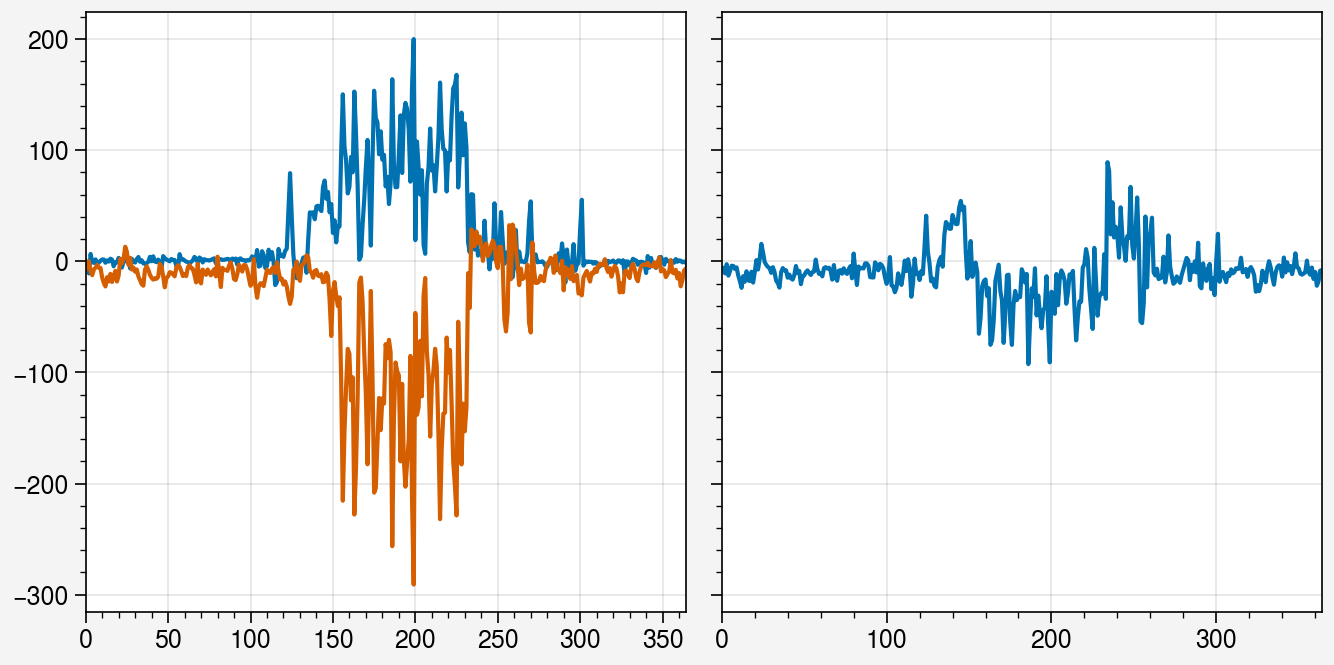

In [38]:
x=46
y=40

f,ax=pplt.subplots(ncols=2,axwidth=3)
#ax[0].plot(SWD[86:101,x,y]-SWU[86:101,x,y]+LWD[86:101,x,y]-LWU[86:101,x,y]+SHF[86:101,x,y]+LHF[86:101,x,y])
#ax[0].plot(snowmelt[85:100,x,y])
ax[0].plot(SWD[1:,x,y]-SWU[1:,x,y]+LWD[1:,x,y]-LWU[1:,x,y]+SHF[1:,x,y]+LHF[1:,x,y])
ax[0].plot(snowmelt[:,x,y])

ax[1].plot(SWD[1:,x,y]-SWU[1:,x,y]+LWD[1:,x,y]-LWU[1:,x,y]+SHF[1:,x,y]+LHF[1:,x,y] + snowmelt[:,x,y])

<a list of 1 Line2D objects>

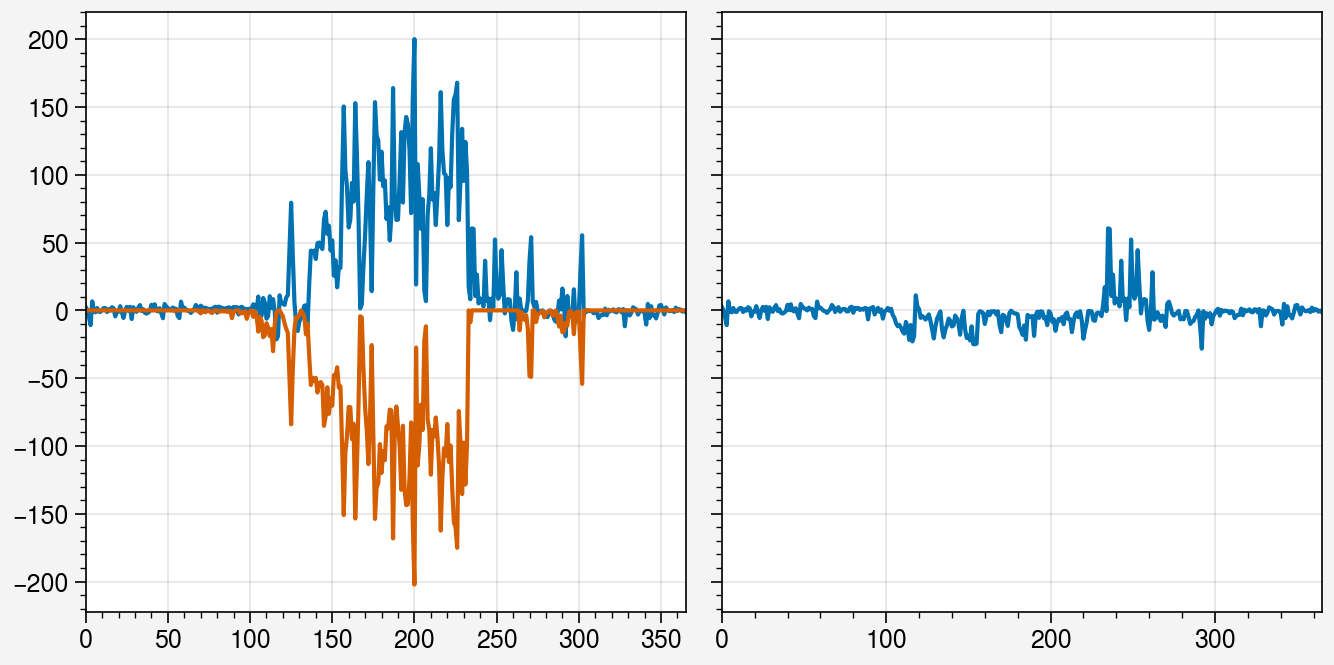

In [101]:
x=46
y=40

f,ax=pplt.subplots(ncols=2,axwidth=3)
ax[0].plot(SWD[:,x,y]-SWU[:,x,y]+LWD[:,x,y]-LWU[:,x,y]+SHF[:,x,y]+LHF[:,x,y])
ax[0].plot(-flux_melt_MBm[:,x,y])

ax[1].plot(SWD[:,x,y]-SWU[:,x,y]+LWD[:,x,y]-LWU[:,x,y]+SHF[:,x,y]+LHF[:,x,y] - flux_melt_MBm[:,x,y])